# TP3

## Exercice 1

### a

In [ ]:
import pandas as pd
import lxml
tables = pd.read_html('https://statistique.quebec.ca/fr/document/noms-de-famille-au-quebec/tableau/estimation-de-leffectif-des-1-000-premiers-noms-de-famille-par-ordre-alphabetique-quebec-2005')


In [ ]:
type(tables)

### b

On récupère une liste

In [ ]:
df = tables[0]
df.to_csv('brut.csv', index=False)

### c

In [ ]:
df = pd.read_csv('brut.csv')
print(df.head())
print(df.tail(10))

In [ ]:
df = df.dropna(thresh=5)
df = df.iloc[0:250]

### d


In [ ]:
df1 = df.iloc[:, 0:4]
df2 = df.iloc[:, 4:8]
df3 = df.iloc[:, 8:12]
df4 = df.iloc[:, 12:15]

### e

In [ ]:
df1 = df1.drop(df1.columns[3], axis=1)
df2 = df2.drop(df2.columns[3], axis=1)
df3 = df3.drop(df3.columns[3], axis=1)

In [ ]:
nouveaux_noms = ['rang', 'nom', 'nombre']
df1.columns = nouveaux_noms
df2.columns = nouveaux_noms
df3.columns = nouveaux_noms
df4.columns = nouveaux_noms

### f

In [ ]:
df = pd.concat([df1, df2, df3, df4])
df

### g

In [ ]:
df.to_csv('noms0.csv', index=True)

## Exercice 2

### a

In [88]:
df = pd.read_csv('noms0.csv', index_col=0)
df
df.sort_values('rang')


,rang,nom,nombre
211,1,Tremblay,81 500
14,1 000,André,1 200
142,10,Gagné,33 900
86,100,Larouche,11 000
117,101,Legault,10 900
...,...,...,...
13,995,Juteau,1 200
127,996,Forcier,1 200
49,997,Pinsonneault,1 200
231,998,Hervieux,1 200


Le problème est qu'en triant par ordre croissant, on a en deuxième place le rang 1000 alors qu'il est censé être  la fin.

### b

In [ ]:
df['rang'].astype(int)

On a se message d'erreur qui est renvoyé ValueError: invalid literal for int() with base 10: '1 000'
Cela signifie que le nombre 1000 ne peut pas être transformé dû à son espace

### c

In [89]:
def asint(text):
    texte_str = str(text)
    texte_sans_espace = "".join(texte_str.split())
    return int(texte_sans_espace)

### d

In [95]:
df['rang'] = df['rang'].apply(asint)
df['nombre'] = df['nombre'].apply(asint)
df = df.sort_values('rang')
df

,rang,nom,nombre
211,1,Tremblay,81500
143,2,Gagnon,59800
132,3,Roy,57000
243,4,Côté,52300
120,5,Bouchard,40100
...,...,...,...
127,996,Forcier,1200
49,997,Pinsonneault,1200
231,998,Hervieux,1200
19,999,Daraiche,1200


In [99]:
df = df.reset_index(drop=True)

### e

In [101]:
df35 = df.iloc[:35]

In [107]:
print(df35[df35['nom'] == 'Tremblay'])

   rang       nom  nombre
0     1  Tremblay   81500


## Exercice 3

### a

In [112]:
temp=pd.read_csv('temperature-quotidienne-departementale.csv', sep=';')
temp

,Date,Code INSEE département,Département,TMin (°C),TMax (°C),TMoy (°C)
0,2026-08-31,93,Seine-Saint-Denis,17.40,22.60,20.00
1,2026-08-31,30,Gard,15.87,28.23,22.05
2,2026-08-31,35,Ille-et-Vilaine,15.60,23.05,19.32
3,2026-08-31,37,Indre-et-Loire,16.50,24.50,20.50
4,2026-08-31,40,Landes,17.90,26.10,22.00
...,...,...,...,...,...,...
303835,2018-01-01,04,Alpes-de-Haute-Provence,5.50,11.50,8.50
303836,2018-01-01,72,Sarthe,7.70,11.90,9.80
303837,2018-01-01,56,Morbihan,7.70,12.10,9.90
303838,2018-01-01,41,Loir-et-Cher,6.25,9.65,7.95


In [119]:
temp['Date'] = pd.to_datetime(temp['Date'])
type(temp['Date'][0])

pandas._libs.tslibs.timestamps.Timestamp

### b

In [126]:
temp3=temp[temp['Département'].isin(['Gard', 'Hérault', 'Landes'])]
temp3

,Date,Code INSEE département,Département,TMin (°C),TMax (°C),TMoy (°C)
1,2026-08-31,30,Gard,15.87,28.23,22.05
4,2026-08-31,40,Landes,17.90,26.10,22.00
24,2026-08-31,34,Hérault,21.10,32.40,26.75
126,2026-08-30,30,Gard,15.57,29.80,22.68
129,2026-08-30,40,Landes,19.30,28.40,23.85
...,...,...,...,...,...,...
303697,2018-01-02,30,Gard,1.33,10.20,5.77
303740,2018-01-02,40,Landes,9.23,15.23,12.23
303753,2018-01-01,40,Landes,8.50,13.53,11.02
303793,2018-01-01,30,Gard,4.13,8.93,6.53


### c

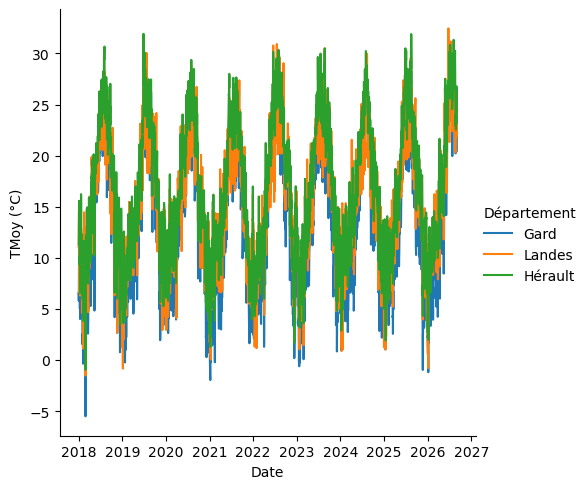

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.relplot(data=temp3, x='Date', y='TMoy (°C)', hue='Département', kind='line')
plt.show()

Les dates sont trop rapprochées et les variations trop fortes pour avoir une bonne lisibilité

### d

In [ ]:
def lissage (df, colonne, methode, fenetre):
    temp3_pivot = temp3.pivot(index='Date', columns='Département', values='TMoy (°C)')
    temp3_lisse = temp3_pivot.rolling(fenetre).agg(methode)
    temp3_lisse = temp3_lisse.reset_index()
    temp3_final = temp3_lisse.melt(
        id_vars='Date', 
        var_name='Département', 
        value_name=colonne)
    return temp3_final

In [ ]:
df = lissage(temp3, 'TMoy (°C)', 'mean', '60d')

,Date,Département,TMoy (°C)
0,2018-01-01,Gard,6.530000
1,2018-01-02,Gard,6.150000
2,2018-01-03,Gard,7.150000
3,2018-01-04,Gard,7.992500
4,2018-01-05,Gard,8.360000
...,...,...,...
9490,2026-08-27,Landes,25.143000
9491,2026-08-28,Landes,25.110000
9492,2026-08-29,Landes,25.122500
9493,2026-08-30,Landes,25.163667


### e

### f

### g